[\[GitHub\] Jupyter Notebook](https://github.com/sslastochkin/mcab/blob/main/docs/guide/07_non_randomized.ipynb)

# Non-Randomized (Constructed) Controls  
  
> **⏭️ You can skip this section** if you are running a standard randomized A/B test where
> users (or other units) are randomly assigned to test and control groups.
> Everything in this section is specific to **non-randomized, constructed controls** —
> situations where the control group is not drawn from the same pool as the test group,
> but is instead *artificially constructed* to be statistically comparable.
>
> **Who this section is for:** practitioners running geo-level experiments, store-level
> interventions, or any setup where synthetic/matched controls are built from historical
> or observational data (e.g., synthetic control method, matched store testing,
> difference-in-differences with constructed counterfactuals).

---

## The Problem

Suppose you are running a store-level experiment. You have selected **N test stores**
that received some treatment (a new promotion, a layout change, etc.) and for each
test store you have **constructed a synthetic control** — a weighted combination of
other stores chosen to closely mimic the test store's pre-experiment trajectory.

This setup has a fundamental structural constraint:

> **The test store and its synthetic control are a locked pair.**
> They were matched precisely because they behave similarly under H₀.
> Breaking this pairing — e.g., randomly reassigning which stores are "test" and
> which are "control" — would destroy the matching and invalidate H₀.

Because of this, the statistical unit of analysis is not the individual store, but
the **per-store difference**:

$$d_i = y_i^{\text{test}} - y_i^{\text{synth}}, \quad i = 1, \ldots, N$$

Under H₀ (no treatment effect), these differences should be centered around zero —
the synthetic control is "as good as" the actual test store, up to noise.

Two questions follow naturally:

1. **Is the synthetic control actually comparable?**
   → Check whether a statistical test on the differences fails to reject H₀.

2. **Can the chosen statistical test correctly handle this data structure?**
   → This is what `DesignerDept1s` and its `aa_sims` are designed to answer.


Number of stores:          60
Mean test revenue:         $88,954
Mean synthetic revenue:    $89,236
Mean difference (d_i):     $-282
Std of differences:        $3,323


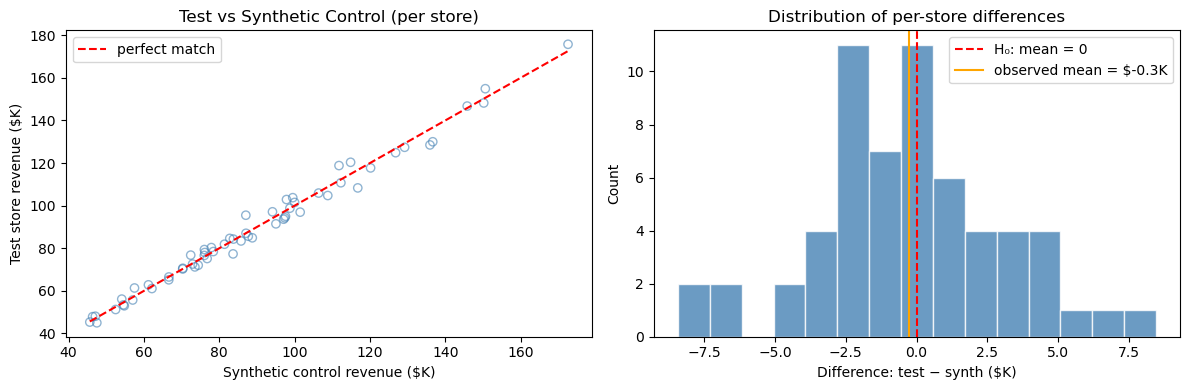

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── Simulate store-level data ──────────────────────────────────────────────────
# Imagine 60 stores. Each has a "true" baseline weekly revenue (log-normal).
# The synthetic control was constructed to track this baseline closely.
# Under H₀ (no treatment), both test revenue and synthetic control revenue
# are baseline + independent noise.

np.random.seed(42)
N_STORES = 60

# Baseline weekly revenue per store (~$90K, log-normal)
baseline = np.random.lognormal(mean=11.4, sigma=0.35, size=N_STORES)

# Test period revenue: baseline + small independent noise (~3%)
data_test = baseline + np.random.normal(0, baseline * 0.03, size=N_STORES)

# Synthetic control revenue: same baseline + independent noise (~3%)
# (well-constructed synthetic control — noise level comparable to test)
data_synth = baseline + np.random.normal(0, baseline * 0.03, size=N_STORES)

differences = data_test - data_synth

# ── Quick sanity check ─────────────────────────────────────────────────────────
print(f"Number of stores:          {N_STORES}")
print(f"Mean test revenue:         ${data_test.mean():,.0f}")
print(f"Mean synthetic revenue:    ${data_synth.mean():,.0f}")
print(f"Mean difference (d_i):     ${differences.mean():,.0f}")
print(f"Std of differences:        ${differences.std():,.0f}")

# ── Visualize differences ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(data_synth / 1000, data_test / 1000, alpha=0.6, edgecolors='steelblue', facecolors='none')
axes[0].plot([data_synth.min() / 1000, data_synth.max() / 1000],
             [data_synth.min() / 1000, data_synth.max() / 1000],
             'r--', label='perfect match')
axes[0].set_xlabel('Synthetic control revenue ($K)')
axes[0].set_ylabel('Test store revenue ($K)')
axes[0].set_title('Test vs Synthetic Control (per store)')
axes[0].legend()

axes[1].hist(differences / 1000, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', label='H₀: mean = 0')
axes[1].axvline(differences.mean() / 1000, color='orange', linestyle='-', label=f'observed mean = ${differences.mean()/1000:.1f}K')
axes[1].set_xlabel('Difference: test − synth ($K)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of per-store differences')
axes[1].legend()

plt.tight_layout()
plt.show()


## Step 1: Checking Comparability — Is H₀ Plausible?

Before running any inference, we should verify that the synthetic control is actually
comparable to the test stores in the first place.

We wrap the data in `AaDataDept1s`, which internally computes
`data_mod = data_test − data_synth` and uses it as the working metric for all
downstream simulations.

Then we apply a **one-sample t-test** to ask:
> *"Is the mean of the per-store differences statistically indistinguishable from zero?"*

If `p-value > α`, we have no statistical evidence against comparability — the synthetic
control is doing its job.


In [2]:
from mcab.core import AaDataDept1s, DesignerDept1s

# ── Wrap data in AaDataDept1s ──────────────────────────────────────────────────
aa_data = AaDataDept1s(data_test=data_test, data_synt=data_synth)

print("AaDataDept1s internals:")
print(f"  data_mod = data_test − data_synth")
print(f"  mean(data_mod) = {aa_data.data_mod.mean():,.1f}")
print(f"  std(data_mod)  = {aa_data.data_mod.std():,.1f}")
print(f"  N              = {len(aa_data.data_mod)}")

# ── Single comparability check: one-sample t-test on differences ───────────────
t_stat, p_value = stats.ttest_1samp(aa_data.data_mod, popmean=0)

print(f"\nOne-sample t-test  (H₀: mean difference = 0)")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_value:.4f}")

if p_value > 0.05:
    print("  ✅ p > 0.05 — no evidence against H₀. Control and test are comparable.")
else:
    print("  ⚠️  p ≤ 0.05 — the synthetic control may not be well-matched.")
    print("     Consider revisiting the matching procedure before running inference.")


AaDataDept1s internals:
  data_mod = data_test − data_synth
  mean(data_mod) = -281.9
  std(data_mod)  = 3,323.1
  N              = 60

One-sample t-test  (H₀: mean difference = 0)
  t-statistic : -0.6517
  p-value     : 0.5172
  ✅ p > 0.05 — no evidence against H₀. Control and test are comparable.


## Step 2: Validating the Statistical Test — Does It Control Type I Error?

Passing the comparability check above tells us:

> *"The synthetic control is comparable to the test stores over the data period."*

But it does **not** tell us:

> *"The statistical test we plan to use actually controls type I error at the
> intended level α when applied to this data."*

This is a subtle but critical distinction. The differences `d_i = test_i − synth_i`
may have:

- **Skewed or heavy-tailed distributions** (if store revenue is log-normal)
- **Heteroscedastic noise** (larger stores have larger absolute deviations)
- **Small sample sizes** (30–100 stores is common in geo experiments)

Under these conditions, a standard one-sample t-test may reject H₀ **too often or
too rarely** — giving you false confidence in your conclusions.

**`DesignerDept1s.aa_sims`** solves this by running thousands of synthetic AA tests:
it repeatedly resamples from the observed differences and applies your chosen test,
measuring the empirical false-positive rate (FPR). If the FPR ≈ α, the test is valid
for your data. If not, you need a different test.

> Below we compare two candidate tests:
> 1. **One-sample t-test** — parametric, assumes approximately normal differences
> 2. **Sign-flip permutation test** — non-parametric, valid under H₀ by construction


AA simulations — one-sample t-test


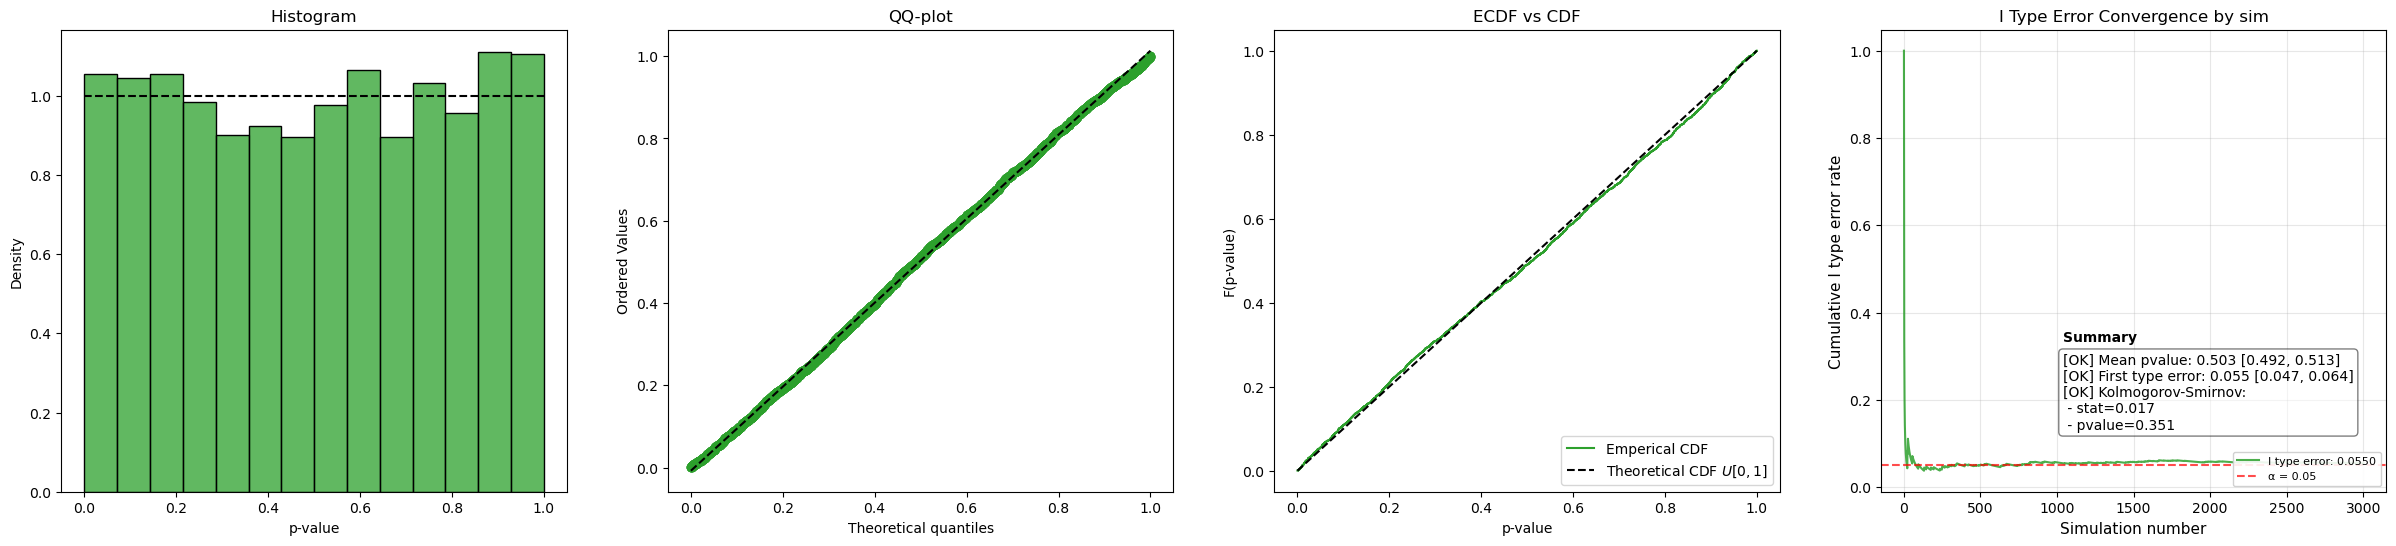

In [3]:
# ── DesignerDept1s + aa_sims: one-sample t-test ───────────────────────────────
designer = DesignerDept1s(
    target=aa_data,
    alpha=0.05,
    seed=42,
    name='Store-level (paired diffs)'
)

# For DesignerDept1s, pval_func receives a single 1-D array of resampled
# per-store differences. It does NOT receive a separate control group —
# the synthetic control is already "baked in" to the differences.
pval_ttest = lambda diffs: stats.ttest_1samp(diffs, popmean=0).pvalue

print("=" * 55)
print("AA simulations — one-sample t-test")
print("=" * 55)
pvalues_ttest = designer.aa_sims(
    pval_func=pval_ttest,
    n_sims=3000,
    verbose=False,
    plot=True,
    n_jobs=-1
)


AA simulations — sign-flip permutation test


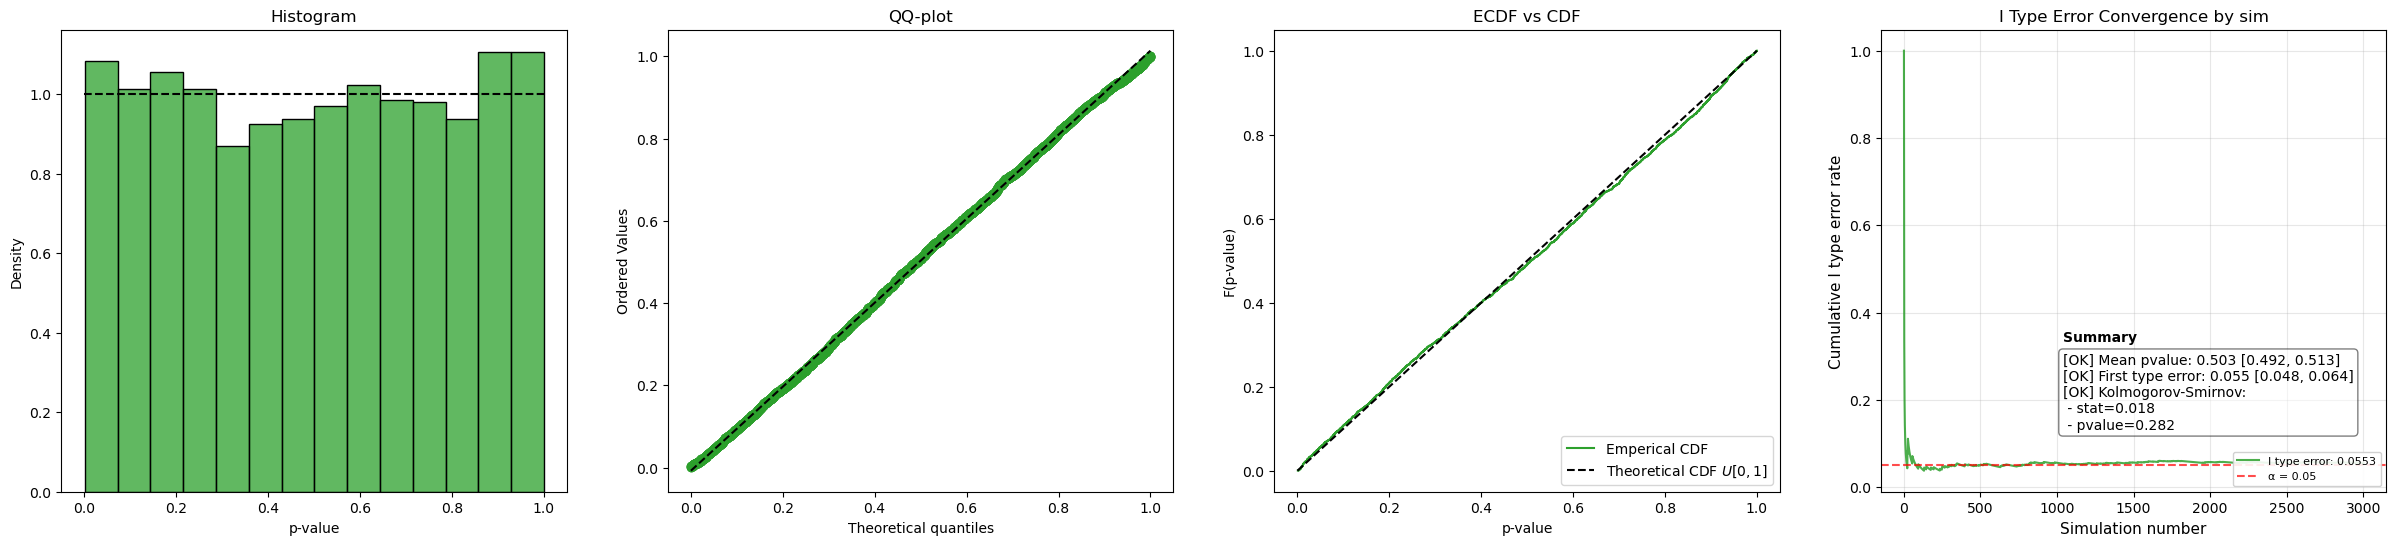


Test                                  Empirical FPR   vs α=0.05
--------------------------------------------------------------
One-sample t-test                             0.055        ✅ OK
Sign-flip permutation test                    0.055        ✅ OK


In [4]:
# ── aa_sims: sign-flip permutation test (non-parametric alternative) ──────────
# Under H₀ the sign of each difference d_i is equally likely to be + or −.
# We randomly flip signs and measure how extreme the observed mean is.

def pval_signflip(diffs, n_perms: int = 999):
    """
    One-sample sign-flip permutation test.
    H₀: distribution of `diffs` is symmetric around 0.
    pval_func signature for DesignerDept1s: (diffs: ndarray) -> float
    """
    observed = np.abs(np.mean(diffs))
    rng = np.random.default_rng()
    signs = rng.choice([-1.0, 1.0], size=(n_perms, len(diffs)))
    perm_means = np.abs(np.mean(diffs * signs, axis=1))
    return (np.sum(perm_means >= observed) + 1) / (n_perms + 1)

print("=" * 55)
print("AA simulations — sign-flip permutation test")
print("=" * 55)
pvalues_perm = designer.aa_sims(
    pval_func=pval_signflip,
    n_sims=3000,
    verbose=False,
    plot=True,
    n_jobs=-1,
)

# ── Side-by-side FPR summary ─────────────────────────────────────────────────
alpha = 0.05
fpr_ttest = np.mean(pvalues_ttest < alpha)
fpr_perm  = np.mean(pvalues_perm  < alpha)

print(f"\n{'Test':<35} {'Empirical FPR':>15}  {'vs α=0.05':>10}")
print("-" * 62)
print(f"{'One-sample t-test':<35} {fpr_ttest:>15.3f}  {'✅ OK' if abs(fpr_ttest - alpha) < 0.015 else '⚠️  off':>10}")
print(f"{'Sign-flip permutation test':<35} {fpr_perm:>15.3f}  {'✅ OK' if abs(fpr_perm  - alpha) < 0.015 else '⚠️  off':>10}")


## Interpreting the Results

| Empirical FPR | Meaning | Action |
|---|---|---|
| FPR ≈ α (e.g. 0.04–0.06) | ✅ The test correctly controls type I error | Safe to use for real experiment inference |
| FPR >> α (e.g. > 0.08) | ⚠️ The test is anti-conservative — too many false positives | Switch to a more robust test (permutation, bootstrap) |
| FPR << α (e.g. < 0.02) | ℹ️ The test is overly conservative — too few rejections | Power will be lower than expected; reconsider the test |

In our store-level example with ~3% noise and 60 stores, the one-sample t-test
tends to work well because the differences are approximately normal (CLT kicks in).
The sign-flip permutation test is valid by construction and makes an excellent
non-parametric baseline.

In practice, if your stores have **very skewed revenue** (e.g. a few flagship stores
dominate), the t-test FPR may inflate. The sign-flip permutation test is robust to
this and is generally recommended for geo/store experiments.

---

## Checklist: Working with Non-Randomized Controls

1. **Verify comparability** — run a one-sample t-test (or equivalent) on the
   per-unit differences `d_i = test_i − synth_i`. If `p > α`, the synthetic
   control is statistically comparable for the period in your data.

2. **Validate your test with `aa_sims`** — confirm that the statistical test you
   intend to use actually controls type I error at the intended level α. If
   empirical FPR >> α, switch to a non-parametric alternative.

3. **Only then run the real A/B analysis** — apply the validated test to your
   experiment-period differences to make causal inference about the treatment effect.

> **Note:** Steps 1 and 2 use the *same pre-experiment data* used to build the
> synthetic control. They do not touch the experiment period and carry no
> multiple-testing cost for the final inference.
